# Control analysis: correlation of single-cell activity with running

For each cell in each session in the platform paper experiment table:
1. Trial-to-trial correlation of `mean_response` (500 ms post-stim window) with `mean_running_speed` (500 ms post-stim window).
2. Running modulation index (RMI): mean response when running > 2 cm/s divided by mean response when running < 2 cm/s.

Then plot distributions of both metrics by `cell_type` x `experience_level`, and show single-cell examples for two Vip cells (one with high activity-running correlation, one with high RMI).

Data: `loading.get_stimulus_response_df(dataset, event_type='all')` returns one row per (cell, stimulus_presentation) with `mean_response` and `mean_running_speed` columns after merging the annotated stimulus_presentations table.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from joblib import Parallel, delayed

sns.set_context('notebook', font_scale=1.2, rc={'lines.markeredgewidth': 2})

import visual_behavior.data_access.loading as loading
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
plot_save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'running_activity_correlation')
if not os.path.exists(plot_save_dir):
    os.makedirs(plot_save_dir)

# Cache directory for per-cell metrics (so we don't re-loop the cache every run)
metrics_save_dir = "C:\\Users\\marinag\\Dropbox\\JupyterNotebooks\\FinalDataAssetsforCodeOcean\\visual_behavior_ophys_analysis_files\\cell_metrics"
metrics_cache_dir = os.path.join(metrics_save_dir, 'running_metrics')
if not os.path.exists(metrics_cache_dir):
    os.makedirs(metrics_cache_dir)

experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()
exp_palette = utils.get_experience_level_colors()


## Load metadata

In [10]:
cache_dir = loading.get_platform_analysis_cache_dir()
platform_experiments = pd.read_csv(
    os.path.join(cache_dir, 'platform_paper_ophys_experiments_table.csv'),
    index_col=0,
)
print(len(platform_experiments), 'experiments')
platform_experiments.head(2)

402 experiments


,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,...,layer,area_layer,date,first_novel,n_relative_to_first_novel,last_familiar,last_familiar_active,second_novel,second_novel_active,experience_exposure
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,
795073741,794968300,794918442,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181213,False,-1.0,True,True,False,False,Familiar 3
795953296,795742990,795625712,791352433,412036,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,['Vip-IRES-Cre'],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,...,upper,VISp_upper,20181214,True,0.0,False,False,False,False,Novel 0



## Steady-state stimulus presentation filter

Restrict correlation/RMI computation to repeated-image flashes at steady state. Exclude:
- omissions and the flash immediately after an omission (`post_omitted`)
- image changes
- the 4 flashes following each change (covers the change response + reward-consumption window)

Implemented with `time_from_last_change > 4 * FLASH_PERIOD` (flash period = 0.75 s in VBO). Applied in both the per-cell metric computation and the single-cell example loaders so the population stats and the example plots use the same trial set.


In [11]:

FLASH_PERIOD = 0.75  # seconds (VBO stim cycle)
N_FLASHES_POSTCHANGE_EXCLUDE = 4


def filter_steady_state_presentations(sdf, n_flashes_postchange=N_FLASHES_POSTCHANGE_EXCLUDE,
                                      flash_period=FLASH_PERIOD):
    """Restrict to repeated-image flashes at steady state.
    Excludes omissions, post-omissions, changes, and the n flashes following each change."""
    postchange_window = n_flashes_postchange * flash_period  # seconds since last change to exclude
    mask = (
        (~sdf['omitted'].astype(bool))
        & (~sdf['post_omitted'].fillna(False).astype(bool))
        & (~sdf['is_change'].astype(bool))
        & (sdf['time_from_last_change'] > postchange_window)
    )
    return sdf[mask].copy()



## Per-cell metric computation


Given a stimulus_response_df for one experiment, compute for each cell:
- `activity_running_corr`, `activity_running_pval` — Pearson correlation of `mean_response` with `mean_running_speed` across stimulus presentations.
- `running_modulation_index` — `(mean_run - mean_stationary) / (mean_run + mean_stationary)`, bounded [-1, 1].
- `n_run_trials`, `n_stationary_trials` — sample sizes for the two running conditions.

Uses `event_type='all'` (all stimulus presentations) per the spec.



In [12]:
RUN_THRESH = 2.0  # cm/s
MIN_TRIALS_PER_CONDITION = 5  # require at least this many stim presentations per run/stationary for RMI


def compute_running_metrics_for_experiment(sdf, run_thresh=RUN_THRESH, min_trials=MIN_TRIALS_PER_CONDITION):
    """Per-cell correlation of mean_response with mean_running_speed and running modulation index.
    Operates on the steady-state subset of stimulus presentations (see filter_steady_state_presentations)."""
    sdf = filter_steady_state_presentations(sdf)
    rows = []
    for csid, cell_df in sdf.groupby('cell_specimen_id'):
        # drop rows missing either metric
        d = cell_df[['mean_response', 'mean_running_speed']].dropna()
        if len(d) < 10:
            continue
        r, p = stats.pearsonr(d['mean_response'].values, d['mean_running_speed'].values)

        run_mask = d['mean_running_speed'] > run_thresh
        stationary_mask = d['mean_running_speed'] < run_thresh
        n_run = int(run_mask.sum())
        n_stationary = int(stationary_mask.sum())
        mean_run = d.loc[run_mask, 'mean_response'].mean() if n_run >= min_trials else np.nan
        mean_stationary = d.loc[stationary_mask, 'mean_response'].mean() if n_stationary >= min_trials else np.nan
        # normalized modulation index, bounded [-1, 1]
        denom = mean_run + mean_stationary
        with np.errstate(divide='ignore', invalid='ignore'):
            rmi = (mean_run - mean_stationary) / denom if (denom not in (0, np.nan)) else np.nan

        rows.append({
            'cell_specimen_id': csid,
            'activity_running_corr': r,
            'activity_running_pval': p,
            'running_modulation_index': rmi,
            'mean_response_run': mean_run,
            'mean_response_stationary': mean_stationary,
            'n_run_trials': n_run,
            'n_stationary_trials': n_stationary,
            'n_trials_total': len(d),
        })
    return pd.DataFrame(rows)

## Loop over experiments (parallel)

Each worker loads `get_stimulus_response_df` for one experiment, computes per-cell metrics, and writes a small per-experiment CSV to `per_exp_cache_dir`. The outer loop skips experiments whose per-experiment file already exists, so the run is restartable / incrementally cacheable. After the parallel sweep, the per-experiment files are concatenated into `running_metrics_table.csv`.

Set `N_JOBS` based on your machine's memory — each worker holds a full dataset object. Start with 4 and bump up if RAM allows.


In [13]:
N_JOBS = 4  # adjust based on available RAM
OVERWRITE_METRICS = True  # set True to force re-run; clears per-experiment cache
metrics_filepath = os.path.join(metrics_save_dir, 'running_metrics_table.csv')


def process_one_experiment(oeid, per_exp_dir):
    """Worker: load sdf for one experiment, compute per-cell metrics, save per-experiment CSV.
    Skips work if the per-experiment CSV already exists. Returns (oeid, status_str)."""
    out_path = os.path.join(per_exp_dir, f'{oeid}_running_metrics.csv')
    if os.path.exists(out_path):
        return oeid, 'cached'
    try:
        dataset = loading.get_ophys_dataset(oeid)
        sdf = loading.get_stimulus_response_df(
            dataset,
            time_window=[-2, 2.1],
            interpolate=True,
            output_sampling_rate=30,
            data_type='events',
            event_type='all',
            load_from_file=True,
        )
        exp_metrics = compute_running_metrics_for_experiment(sdf)
        exp_metrics['ophys_experiment_id'] = oeid
        exp_metrics.to_csv(out_path)
        return oeid, 'ok'
    except Exception as e:
        return oeid, f'failed: {e}'


In [14]:

if OVERWRITE_METRICS:
    # clear per-experiment cache
    for f in os.listdir(metrics_cache_dir):
        if f.endswith('_running_metrics.csv'):
            os.remove(os.path.join(metrics_cache_dir, f))
    if os.path.exists(metrics_filepath):
        os.remove(metrics_filepath)

if os.path.exists(metrics_filepath) and not OVERWRITE_METRICS:
    metrics_table = pd.read_csv(metrics_filepath, index_col=0)
    print('loaded cached metrics:', metrics_filepath)
else:
    experiment_ids = platform_experiments.index.values  
    # experiment_ids = platform_experiments[platform_experiments.cell_type=='Vip Inhibitory'].index.values[:10]
    results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=5)(
        delayed(process_one_experiment)(int(oeid), metrics_cache_dir)
        for oeid in experiment_ids
    )
    # report
    n_ok = sum(1 for _, s in results if s == 'ok')
    n_cached = sum(1 for _, s in results if s == 'cached')
    failures = [(oeid, s) for oeid, s in results if s not in ('ok', 'cached')]
    print(f'{n_ok} processed, {n_cached} from cache, {len(failures)} failed')
    for oeid, s in failures[:10]:
        print(' ', oeid, s)

    # concat per-experiment files
    per_exp_files = [os.path.join(metrics_cache_dir, f) for f in os.listdir(metrics_cache_dir)
                     if f.endswith('_running_metrics.csv')]
    metrics_table = pd.concat([pd.read_csv(f, index_col=0) for f in per_exp_files], ignore_index=True)
    metrics_table.to_csv(metrics_filepath)
    print('saved metrics to', metrics_filepath)

print(len(metrics_table), 'cell x session rows')
metrics_table.head()


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 10.2min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 39.3min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 73.7min
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed: 110.6min
[Parallel(n_jobs=4)]: Done 402 out of 402 | elapsed: 149.2min finished


402 processed, 0 from cache, 0 failed
saved metrics to C:\Users\marinag\Dropbox\JupyterNotebooks\FinalDataAssetsforCodeOcean\visual_behavior_ophys_analysis_files\cell_metrics\running_metrics_table.csv
25935 cell x session rows


,cell_specimen_id,activity_running_corr,activity_running_pval,running_modulation_index,mean_response_run,mean_response_stationary,n_run_trials,n_stationary_trials,n_trials_total,ophys_experiment_id
0,1086489847,0.289520,1.434080e-71,0.934364,0.000566,0.000019,426,3232,3658,1003771765
1,1086489860,0.007554,6.478664e-01,0.286564,0.000178,0.000099,426,3232,3658,1003771765
2,1086489891,0.071938,1.330228e-05,0.827739,0.000251,0.000024,426,3232,3658,1003771765
3,1086489901,-0.005290,7.490859e-01,-1.000000,0.000000,0.000008,426,3232,3658,1003771765
4,1086489847,0.156988,5.486156e-21,0.905734,0.000666,0.000033,1105,2438,3543,1004403369


In [15]:
# Merge cre_line + experience_level from the platform_experiments table; derive cell_type from cre_line
metrics_table = metrics_table.merge(
    platform_experiments[['cell_type', 'experience_level']].reset_index(),
    on='ophys_experiment_id',
    how='left',
)
# metrics_table['cell_type'] = metrics_table['cre_line'].apply(utils.convert_cre_line_to_cell_type)
# normalize experience_level naming
# metrics_table['experience_level'] = metrics_table['experience_level'].apply(utils.convert_experience_level)
print(metrics_table[['cell_type', 'experience_level']].value_counts())

cell_type       experience_level
Excitatory      Novel               7974
                Novel +             7404
                Familiar            7302
Vip Inhibitory  Familiar             794
                Novel +              765
                Novel                718
Sst Inhibitory  Novel                337
                Familiar             321
                Novel +              320
dtype: int64


In [16]:
metrics_table.head()

,cell_specimen_id,activity_running_corr,activity_running_pval,running_modulation_index,mean_response_run,mean_response_stationary,n_run_trials,n_stationary_trials,n_trials_total,ophys_experiment_id,cell_type,experience_level
0,1086489847,0.289520,1.434080e-71,0.934364,0.000566,0.000019,426,3232,3658,1003771765,Vip Inhibitory,Familiar
1,1086489860,0.007554,6.478664e-01,0.286564,0.000178,0.000099,426,3232,3658,1003771765,Vip Inhibitory,Familiar
2,1086489891,0.071938,1.330228e-05,0.827739,0.000251,0.000024,426,3232,3658,1003771765,Vip Inhibitory,Familiar
3,1086489901,-0.005290,7.490859e-01,-1.000000,0.000000,0.000008,426,3232,3658,1003771765,Vip Inhibitory,Familiar
4,1086489847,0.156988,5.486156e-21,0.905734,0.000666,0.000033,1105,2438,3543,1004403369,Vip Inhibitory,Novel


## Distributions by cell type and experience level

In [17]:
def plot_metric_by_celltype_and_experience(
    metrics_table, metric, ylabel=None, ylims=None, plot_type='boxplot', save_name=None,
):
    """Boxplot/violin of `metric` for each cell_type across experience levels.
    Mirrors the layout used in platform_paper_figures.plot_metric_distribution_by_experience."""
    cell_types = utils.get_cell_types()
    experience_levels = utils.get_new_experience_levels()
    colors = utils.get_experience_level_colors()

    fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
    for i, cell_type in enumerate(cell_types):
        ct = metrics_table[metrics_table.cell_type == cell_type].dropna(subset=[metric])
        if plot_type == 'boxplot':
            sns.boxplot(
                data=ct, x='experience_level', y=metric, order=experience_levels,
                palette=colors, hue='experience_level', legend=False,
                width=0.5, fliersize=1, notch=True, boxprops=dict(alpha=0.8), ax=ax[i],
            )
        elif plot_type == 'violinplot':
            sns.violinplot(
                data=ct, x='experience_level', y=metric, order=experience_levels,
                palette=colors, hue='experience_level', legend=False,
                cut=0, inner='quartile', ax=ax[i],
            )
        ax[i].set_title(cell_type)
        ax[i].set_xlabel('')
        ax[i].set_ylabel(ylabel if i == 0 else '')
        if ylims is not None:
            ax[i].set_ylim(ylims)
    sns.despine()
    plt.tight_layout()
    if save_name is not None:
        utils.save_figure(fig, fig.get_size_inches(), plot_save_dir, '', save_name, formats=['.png', '.pdf'])
    return fig, ax

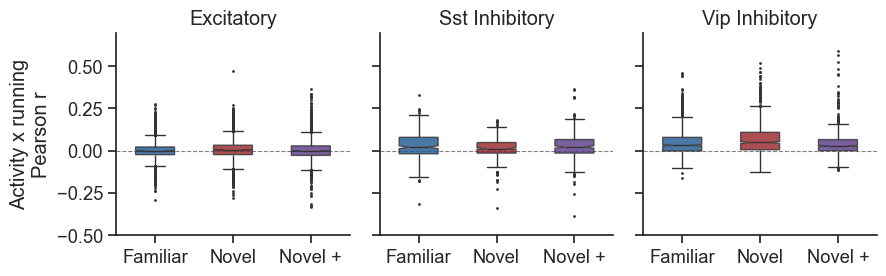

In [18]:
fig, ax = plot_metric_by_celltype_and_experience(
    metrics_table,
    metric='activity_running_corr',
    ylabel='Activity x running\nPearson r',
    ylims=(-0.5, 0.7),
    save_name='activity_running_correlation_by_experience',
)
for a in ax:
    a.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

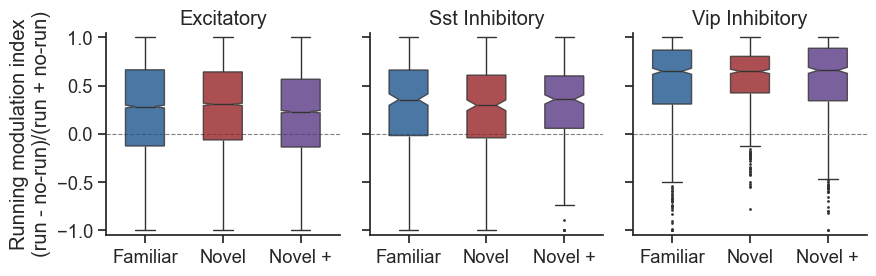

In [19]:
fig, ax = plot_metric_by_celltype_and_experience(
    metrics_table,
    metric='running_modulation_index',
    ylabel='Running modulation index\n(run - no-run)/(run + no-run)',
    ylims=(-1.05, 1.05),
    save_name='running_modulation_index_by_experience',
)
for a in ax:
    a.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

## Single-cell examples

Pick one Vip cell with a high activity-running correlation, and one with a high running modulation index.
Only consider cells with adequate trial counts in both running conditions.

In [20]:
MIN_TRIALS_FOR_EXAMPLES = 30  # per condition

vip = metrics_table[
    (metrics_table.cell_type == 'Vip Inhibitory')
    & (metrics_table.n_run_trials >= MIN_TRIALS_FOR_EXAMPLES)
    & (metrics_table.n_stationary_trials >= MIN_TRIALS_FOR_EXAMPLES)
].copy()

# Pick top by correlation (most positive)
high_corr_row = vip.sort_values('activity_running_corr', ascending=False).iloc[0]
# Pick top by RMI (largest finite ratio)
vip_finite_rmi = vip[np.isfinite(vip.running_modulation_index)]
high_rmi_row = vip_finite_rmi.sort_values('running_modulation_index', ascending=False).iloc[0]

print('high-corr Vip cell:')
print(high_corr_row[['cell_specimen_id', 'ophys_experiment_id', 'activity_running_corr',
                     'activity_running_pval', 'running_modulation_index']])
print('\nhigh-RMI Vip cell:')
print(high_rmi_row[['cell_specimen_id', 'ophys_experiment_id', 'activity_running_corr',
                    'activity_running_pval', 'running_modulation_index']])

high-corr Vip cell:
cell_specimen_id            1086514113
ophys_experiment_id          953443028
activity_running_corr         0.590911
activity_running_pval              0.0
running_modulation_index      0.976681
Name: 16562, dtype: object

high-RMI Vip cell:
cell_specimen_id            1086510811
ophys_experiment_id          848760988
activity_running_corr         0.079433
activity_running_pval         0.000006
running_modulation_index           1.0
Name: 9444, dtype: object


In [21]:
def get_cell_sdf(ophys_experiment_id, cell_specimen_id):
    """Reload stimulus_response_df for one experiment and filter to a single cell."""
    dataset = loading.get_ophys_dataset(ophys_experiment_id)
    sdf = loading.get_stimulus_response_df(
        dataset,
        time_window=[-2, 2.1],
        interpolate=True,
        output_sampling_rate=30,
        data_type='events',
        event_type='all',
        load_from_file=True,
    )
    return sdf[sdf.cell_specimen_id == cell_specimen_id].copy()

In [22]:
def plot_response_vs_running_scatter(cell_sdf, csid, cell_type, r, p, ax=None, save_name=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    else:
        fig = ax.figure
    ax.scatter(cell_sdf['mean_response'], cell_sdf['mean_running_speed'],
               s=8, alpha=0.4, color='k')
    ax.set_xlabel('Mean response')
    ax.set_ylabel('Mean running speed (cm/s)')
    title = f'{cell_type} cell {csid}\nr = {r:.2f}, p = {p:.2f}'
    ax.set_title(title)
    sns.despine(ax=ax)
    if save_name is not None:
        utils.save_figure(fig, fig.get_size_inches(), plot_save_dir, '', save_name, formats=['.png', '.pdf'])
    return ax


def plot_run_vs_stationary_traces(cell_sdf, csid, cell_type, rmi, run_thresh=RUN_THRESH,
                                  ax=None, save_name=None):
    run_df = cell_sdf[cell_sdf['mean_running_speed'] > run_thresh]
    stationary_df = cell_sdf[cell_sdf['mean_running_speed'] < run_thresh]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.5))
    else:
        fig = ax.figure
    ax = utils.plot_stimulus_response_df_trace(
        run_df, time_window=[-1, 1], change=False, omitted=False,
        ylabel='Events', legend_label=f'run > {run_thresh} cm/s (n={len(run_df)})',
        color='tab:red', ax=ax,
    )
    ax = utils.plot_stimulus_response_df_trace(
        stationary_df, time_window=[-1, 1], change=False, omitted=False,
        ylabel='Events', legend_label=f'stationary < {run_thresh} cm/s (n={len(stationary_df)})',
        color='tab:blue', ax=ax,
    )
    ax.legend(fontsize=8, frameon=False)
    title = f'{cell_type} cell {csid}\nrunning modulation index = {rmi:.2f}'
    ax.set_title(title)
    if save_name is not None:
        utils.save_figure(fig, fig.get_size_inches(), plot_save_dir, '', save_name, formats=['.png', '.pdf'])
    return ax

### High activity-running correlation Vip cell

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


file exists:
loading response df from file for 953443028 events all
sdf loaded
4800 stimulus presentations


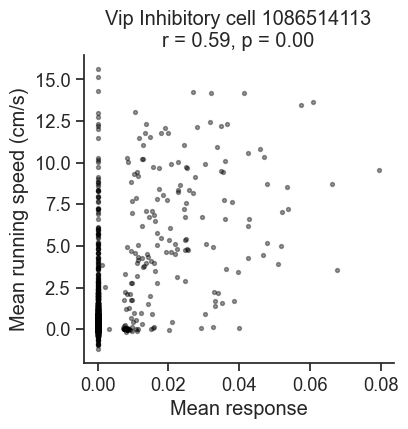

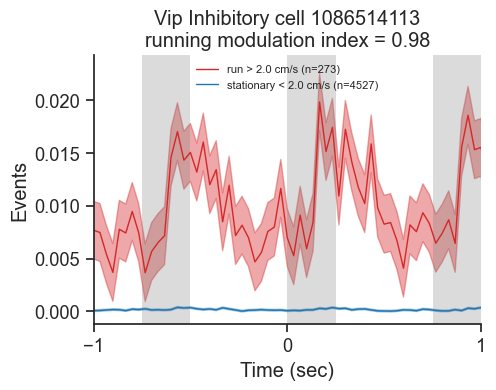

In [23]:
csid = int(high_corr_row['cell_specimen_id'])
oeid = int(high_corr_row['ophys_experiment_id'])
cell_sdf_corr = get_cell_sdf(oeid, csid)
print(len(cell_sdf_corr), 'stimulus presentations')

plot_response_vs_running_scatter(
    cell_sdf_corr, csid, 'Vip Inhibitory',
    r=high_corr_row['activity_running_corr'],
    p=high_corr_row['activity_running_pval'],
    save_name=f'scatter_high_corr_vip_{csid}',
)
plt.show()

plot_run_vs_stationary_traces(
    cell_sdf_corr, csid, 'Vip Inhibitory',
    rmi=high_corr_row['running_modulation_index'],
    save_name=f'traces_high_corr_vip_{csid}',
)
plt.show()

### High running modulation index Vip cell

c:\users\marinag\documents\code\allensdk\allensdk\brain_observatory\behavior\behavior_project_cache\behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


file exists:
loading response df from file for 848760988 events all
sdf loaded
4803 stimulus presentations


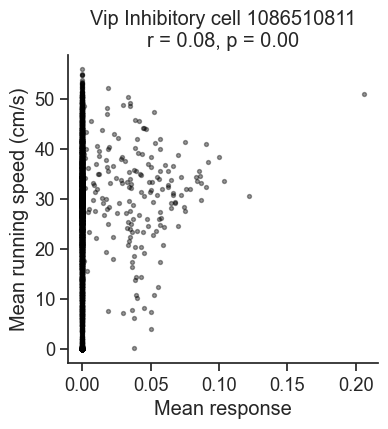

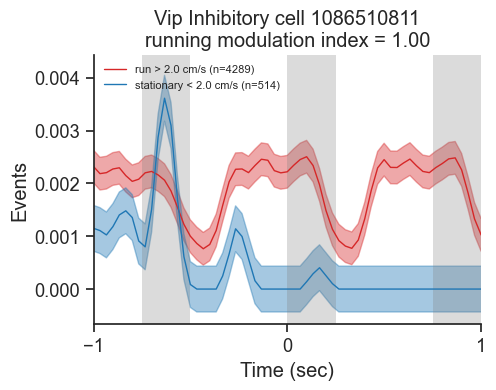

In [24]:
csid = int(high_rmi_row['cell_specimen_id'])
oeid = int(high_rmi_row['ophys_experiment_id'])
cell_sdf_rmi = get_cell_sdf(oeid, csid)
print(len(cell_sdf_rmi), 'stimulus presentations')

plot_response_vs_running_scatter(
    cell_sdf_rmi, csid, 'Vip Inhibitory',
    r=high_rmi_row['activity_running_corr'],
    p=high_rmi_row['activity_running_pval'],
    save_name=f'scatter_high_rmi_vip_{csid}',
)
plt.show()

plot_run_vs_stationary_traces(
    cell_sdf_rmi, csid, 'Vip Inhibitory',
    rmi=high_rmi_row['running_modulation_index'],
    save_name=f'traces_high_rmi_vip_{csid}',
)
plt.show()